### Project 2 : Image Compression with SVD 

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
smooth_image = Image.open("Smooth.jpg")
detailed_image= Image.open("high_details.jpg")
my_image= Image.open("My_image.jpg")


In [3]:
smooth_image_array = np.array(smooth_image)
detailed_image_array = np.array(detailed_image)
my_image_array = np.array(my_image)

In [4]:
#Getting shape with luminance weight
smooth_image_array.shape

(3376, 6000, 3)

In [5]:
#Getting shape with luminance weight
detailed_image_array.shape

(4096, 3072, 3)

In [6]:
#Getting shape with luminance weight
my_image_array.shape

(3000, 4000, 3)

In [7]:
# Convert to grayscale as a 2-D float array for each image
smooth_image_array = smooth_image.convert("L")
smooth_image_array = np.array(smooth_image_array, dtype=np.float64)

In [8]:
smooth_image_array.shape

(3376, 6000)

In [9]:

detailed_image_array = detailed_image.convert("L")
detailed_image_array = np.array(detailed_image_array, dtype=np.float64)

In [10]:
detailed_image_array.shape

(4096, 3072)

In [11]:
my_image_array = my_image.convert("L")
my_image_array = np.array(my_image_array, dtype=np.float64)

In [12]:
my_image_array.shape

(3000, 4000)

#### Caluculating SVD with with full_matrices=False

In [13]:
#Creating a dictionary of three images : 

images = {
    "Picture1": smooth_image_array,
    "Picture2": detailed_image_array,
    "Pic3": my_image_array
}

svd_results = {}

for name, image in images.items():

    U, S, Vt = np.linalg.svd(
        image,
        full_matrices=False
    )

    svd_results[name] = {
        "U": U,
        "S": S,
        "Vt": Vt
    }

    print(name)
    print("Image:", image.shape)
    print("U:", U.shape)
    print("S:", S.shape)
    print("Vt:", Vt.shape)
    print()

Picture1
Image: (3376, 6000)
U: (3376, 3376)
S: (3376,)
Vt: (3376, 6000)

Picture2
Image: (4096, 3072)
U: (4096, 3072)
S: (3072,)
Vt: (3072, 3072)

Pic3
Image: (3000, 4000)
U: (3000, 3000)
S: (3000,)
Vt: (3000, 4000)



##### Reconstruction function 

In [14]:
def reconstruct_image(U, S, Vt, k):

    return (
        (U[:, :k] * S[:k])
        @ Vt[:k, :]
    )

#### Full-rank reconstruction check

In [15]:
#Reconstructing at a minimum of six values of k, including k = 1 and full rank
#checking that full-rank reconstruction returns the original 
k_values = [1, 10, 50, 100, 500]

for name, result in svd_results.items():

    U = result["U"]
    S = result["S"]
    Vt = result["Vt"]

    full_rank = len(S)

    # Adding full rank as the 6th value
    current_k_values = k_values + [full_rank]

    print(f"\n{name}")
    print("Full rank:", full_rank)

    for k in current_k_values:

        reconstructed = reconstruct_image(
            U, S, Vt, k
        )

        print("k =", k)
        print("Reconstructed shape:", reconstructed.shape)


Picture1
Full rank: 3376
k = 1
Reconstructed shape: (3376, 6000)
k = 10
Reconstructed shape: (3376, 6000)
k = 50
Reconstructed shape: (3376, 6000)
k = 100
Reconstructed shape: (3376, 6000)
k = 500
Reconstructed shape: (3376, 6000)
k = 3376
Reconstructed shape: (3376, 6000)

Picture2
Full rank: 3072
k = 1
Reconstructed shape: (4096, 3072)
k = 10
Reconstructed shape: (4096, 3072)
k = 50
Reconstructed shape: (4096, 3072)
k = 100
Reconstructed shape: (4096, 3072)
k = 500
Reconstructed shape: (4096, 3072)
k = 3072
Reconstructed shape: (4096, 3072)

Pic3
Full rank: 3000
k = 1
Reconstructed shape: (3000, 4000)
k = 10
Reconstructed shape: (3000, 4000)
k = 50
Reconstructed shape: (3000, 4000)
k = 100
Reconstructed shape: (3000, 4000)
k = 500
Reconstructed shape: (3000, 4000)
k = 3000
Reconstructed shape: (3000, 4000)


##### Compression ratio

In [16]:
def compression_ratio(m, n, k):

    original_numbers = m * n

    svd_numbers = k * (m + n + 1)

    return original_numbers / svd_numbers

In [17]:
# k and its compression ratio for each picture.
compression_results = []

for name, image in images.items():

    m, n = image.shape

    S = svd_results[name]["S"]

    max_rank = len(S)

    k_values = [
        1,
        5,
        10,
        25,
        50,
        100,
        max_rank
    ]

    # Remove duplicate k values and values larger than rank
    k_values = sorted(
        set(min(k, max_rank) for k in k_values)
    )

    for k in k_values:

        ratio = compression_ratio(
            m,
            n,
            k
        )

        compression_results.append({
            "Image": name,
            "k": k,
            "Compression Ratio": ratio
        })

compression_df = pd.DataFrame(
    compression_results
)

compression_df

,Image,k,Compression Ratio
0,Picture1,1,2160.179162
1,Picture1,5,432.035832
2,Picture1,10,216.017916
3,Picture1,25,86.407166
4,Picture1,50,43.203583
5,Picture1,100,21.601792
6,Picture1,3376,0.639863
7,Picture2,1,1755.183708
8,Picture2,5,351.036742
9,Picture2,10,175.518371


In [18]:
#Defining relative error : 
#To estimate how much error did we make compared with what the correct value actually was?
def relative_error(original, reconstructed):

    return (
        np.linalg.norm(
            original - reconstructed,
            ord="fro"
        )
        /
        np.linalg.norm(
            original,
            ord="fro"
        )
    )

In [19]:
# finding relative error and energy retained for all the images and values of k. 


metrics = []

for name, image in images.items():

    U = svd_results[name]["U"]
    S = svd_results[name]["S"]
    Vt = svd_results[name]["Vt"]

    m, n = image.shape
    max_rank = len(S)

    k_values = [1, 5, 10, 25, 50, 100, max_rank]

    # Remove duplicate/invalid k values
    k_values = sorted(
        set(min(k, max_rank) for k in k_values)
    )

    for k in k_values:

        # Reconstruct image using k components
        reconstructed = (
            (U[:, :k] * S[:k])
            @ Vt[:k, :]
        )

        # 1. Numbers stored
        numbers_stored = k * (m + n + 1)

        # 2. Compression ratio
        compression_ratio_value = (
            (m * n) / numbers_stored
        )

        # 3. Relative Frobenius error
        error = relative_error(
            image,
            reconstructed
        )

        # 4. Energy retained
        energy = (
            np.sum(S[:k] ** 2)
            /
            np.sum(S ** 2)
        )

        metrics.append({
            "Image": name,
            "k": k,
            "Numbers Stored": numbers_stored,
            "Compression Ratio": compression_ratio_value,
            "Relative Error": error,
            "Energy Retained": energy
        })

metrics_df = pd.DataFrame(metrics)

metrics_df

,Image,k,Numbers Stored,Compression Ratio,Relative Error,Energy Retained
0,Picture1,1,9377,2160.179162,6.172396e-02,0.996190
1,Picture1,5,46885,432.035832,2.724021e-02,0.999258
2,Picture1,10,93770,216.017916,1.905348e-02,0.999637
3,Picture1,25,234425,86.407166,1.075166e-02,0.999884
4,Picture1,50,468850,43.203583,6.376474e-03,0.999959
5,Picture1,100,937700,21.601792,3.825756e-03,0.999985
6,Picture1,3376,31656752,0.639863,3.125473e-15,1.000000
7,Picture2,1,7169,1755.183708,4.397660e-01,0.806606
8,Picture2,5,35845,351.036742,3.382336e-01,0.885598
9,Picture2,10,71690,175.518371,2.858387e-01,0.918296


In [20]:
display_df = metrics_df.copy()

display_df["Compression Ratio"] = (
    display_df["Compression Ratio"].round(3)
)

display_df["Relative Error"] = (
    display_df["Relative Error"].round(3)
)

display_df["Energy Retained"] = (
    display_df["Energy Retained"].round(3)
)

display_df

,Image,k,Numbers Stored,Compression Ratio,Relative Error,Energy Retained
0,Picture1,1,9377,2160.179,0.062,0.996
1,Picture1,5,46885,432.036,0.027,0.999
2,Picture1,10,93770,216.018,0.019,1.000
3,Picture1,25,234425,86.407,0.011,1.000
4,Picture1,50,468850,43.204,0.006,1.000
5,Picture1,100,937700,21.602,0.004,1.000
6,Picture1,3376,31656752,0.640,0.000,1.000
7,Picture2,1,7169,1755.184,0.440,0.807
8,Picture2,5,35845,351.037,0.338,0.886
9,Picture2,10,71690,175.518,0.286,0.918


#### Finding smallest k for an energy threshold

In [21]:
def find_energy_k(S, threshold):

    cumulative_energy = (
        np.cumsum(S ** 2)
        /
        np.sum(S ** 2)
    )

    k = (
        np.argmax(
            cumulative_energy >= threshold
        )
        + 1
    )

    return k

In [23]:
energy_results = []

for name, result in svd_results.items():

    S = result["S"]

    k90 = find_energy_k(S, 0.90)
    k99 = find_energy_k(S, 0.99)
    k999 = find_energy_k(S, 0.999)

    energy_results.append({
        "Image": name,
        "90% Energy": k90,
        "99% Energy": k99,
        "99.9% Energy": k999
    })

energy_df = pd.DataFrame(energy_results)

energy_df

,Image,90% Energy,99% Energy,99.9% Energy
0,Picture1,1,1,5
1,Picture2,7,124,405
2,Pic3,1,51,581


- Picture1: Energy is highly concentrated in the first few singular values. Just 1 singular value captures 99% of the total energy, and only 5 are needed for 99.9%.
- Picture2: Energy is spread across more singular values. It requires 7 for 90%, 124 for 99%, and 405 for 99.9%.
- Pic3: The first singular value captures 90% of the energy, but reaching higher thresholds requires many more components: 51 for 99% and 581 for 99.9%.

#### The elbow — plot σᵢ on a log scale against i and identify where the decay changes character.

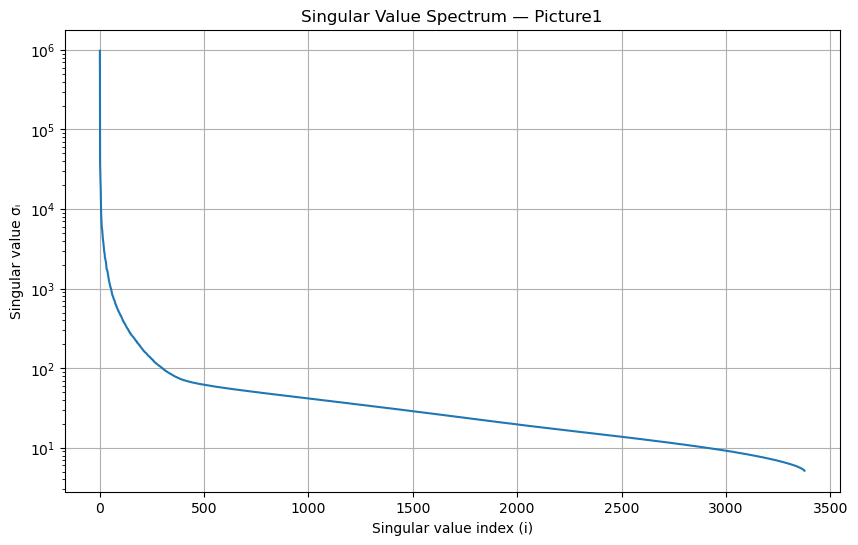

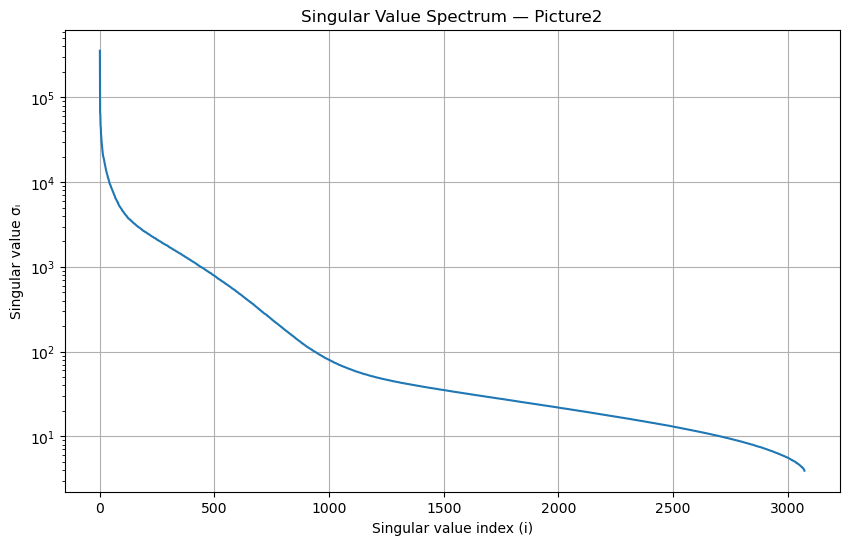

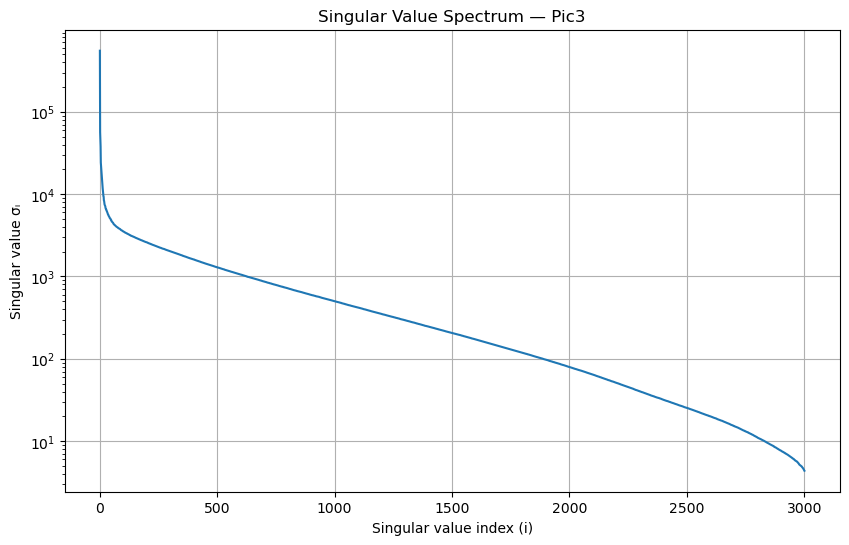

In [24]:
for name, result in svd_results.items():

    S = result["S"]

    plt.figure(figsize=(10, 6))

    plt.semilogy(
        np.arange(1, len(S) + 1),
        S
    )

    plt.xlabel("Singular value index (i)")
    plt.ylabel("Singular value σᵢ")
    plt.title(
        f"Singular Value Spectrum — {name}"
    )

    plt.grid(True)
    plt.show()

##### Graph 1:
- Has the strongest concentration of energy at the beginning.
- The first singular value is dramatically larger than the rest.
- After the initial drop, the spectrum becomes a long, relatively smooth tail.


##### Graph:
- Also starts with a very large first singular value.
- Its spectrum has a more extended transition region before becoming a flatter tail.
- This indicates that information is distributed across more singular components.

##### Graph 3:
- Has a very dominant first singular value, similar to Picture1.
- After the initial steep decline, however, the spectrum decreases gradually across a large number of components.
- This means there is significant information in the longer tail.

In [19]:
def find_elbow(S):

    x = np.arange(
        1,
        len(S) + 1
    )

    y = np.log(
        S + 1e-12
    )

    first_derivative = np.gradient(
        y,
        x
    )

    second_derivative = np.gradient(
        first_derivative,
        x
    )

    k = (
        np.argmax(
            np.abs(second_derivative)
        )
        + 1
    )

    return k

In [20]:
elbow_results = []

for name, result in svd_results.items():

    S = result["S"]

    k = find_elbow(S)

    elbow_results.append({
        "Image": name,
        "Elbow k": k
    })

elbow_df = pd.DataFrame(
    elbow_results
)

elbow_df

,Image,Elbow k
0,Picture1,2
1,Picture2,1
2,Pic3,2


#### A quality target — smallest k with relative error below 5%.

In [25]:
def find_quality_k(
    image,
    U,
    S,
    VT,
    threshold=0.05
):

    for k in range(1, len(S) + 1):

        reconstructed = reconstruct_image(
            U,
            S,
            VT,
            k
        )

        error = relative_error(
            image,
            reconstructed
        )

        if error < threshold:

            return k

    return len(S)

In [26]:
quality_results = []

for name, image in images.items():

    U = svd_results[name]["U"]
    S = svd_results[name]["S"]
    Vt = svd_results[name]["Vt"]

    k = find_quality_k(
        image,
        U,
        S,
        Vt,
        threshold=0.05
    )

    quality_results.append({
        "Image": name,
        "Target": "< 5% Relative Error",
        "Required k": k
    })

quality_df = pd.DataFrame(
    quality_results
)

quality_df

,Image,Target,Required k
0,Picture1,< 5% Relative Error,2
1,Picture2,< 5% Relative Error,294
2,Pic3,< 5% Relative Error,347


The 5% relative-error criterion requires k = 2 for Picture1, k = 294 for Picture2, and k = 347 for Pic3. Picture1 can therefore be approximated with very few components while meeting the error target, whereas Picture2 and Pic3 require substantially more components. The difference between these results and the energy-threshold values demonstrates that high energy retention does not necessarily guarantee low reconstruction error or preservation of fine image details.

#### Displaying all reconstructed version in a grid using different numbers of SVD(k) components


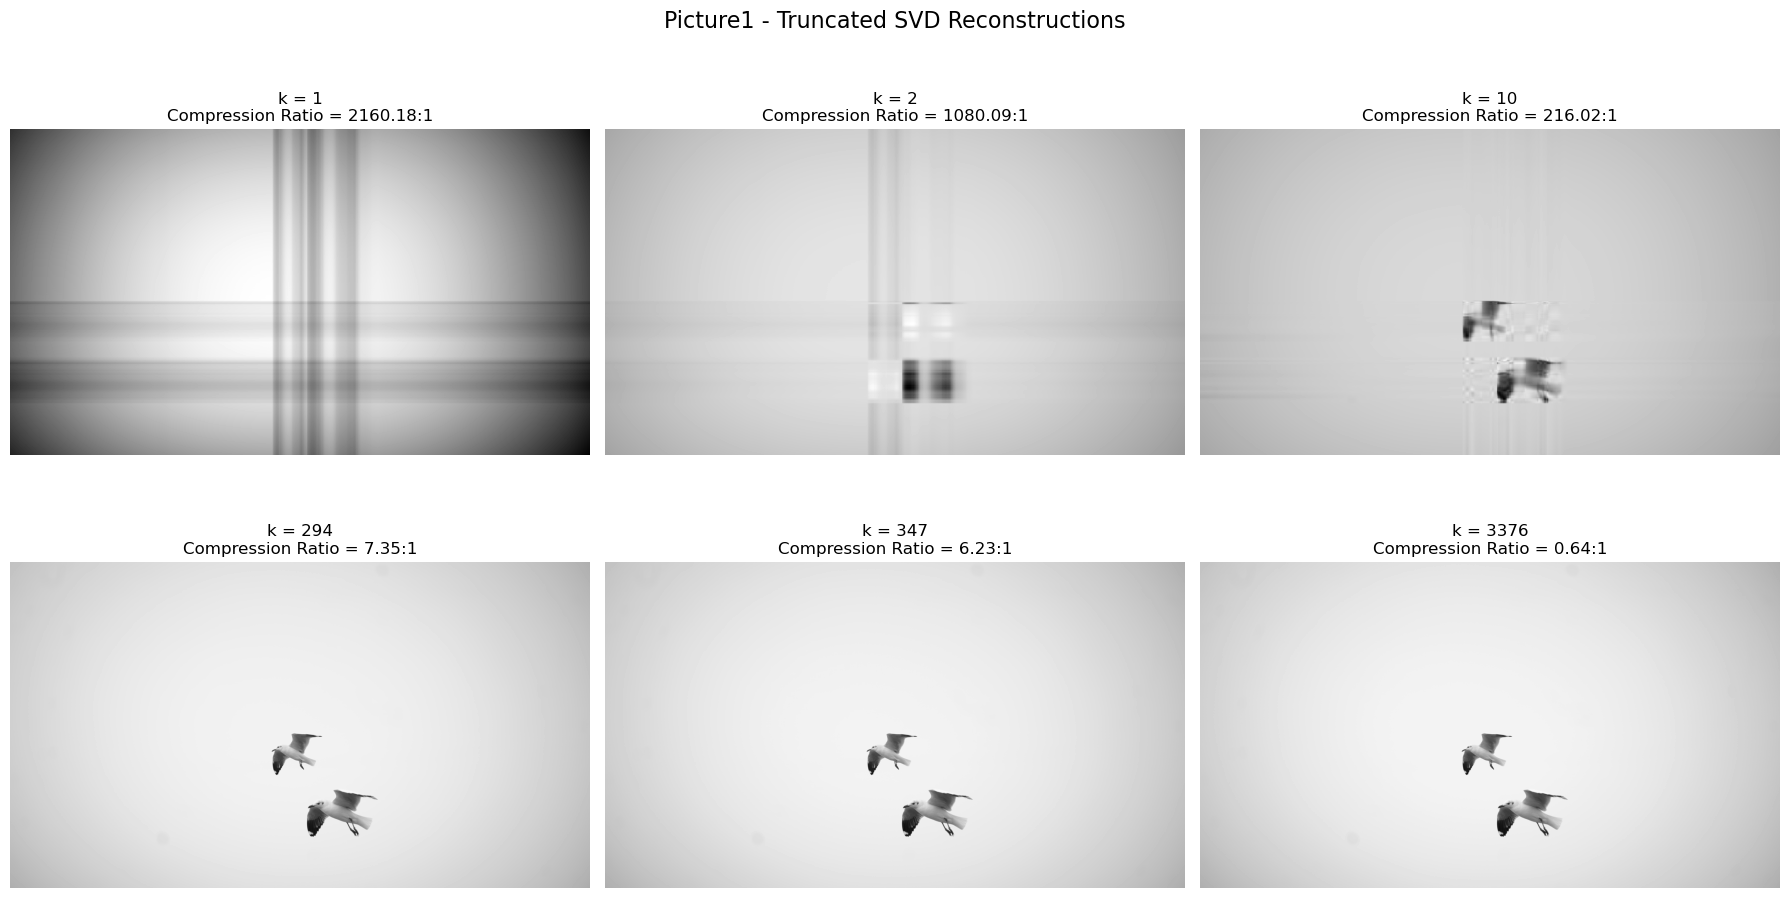

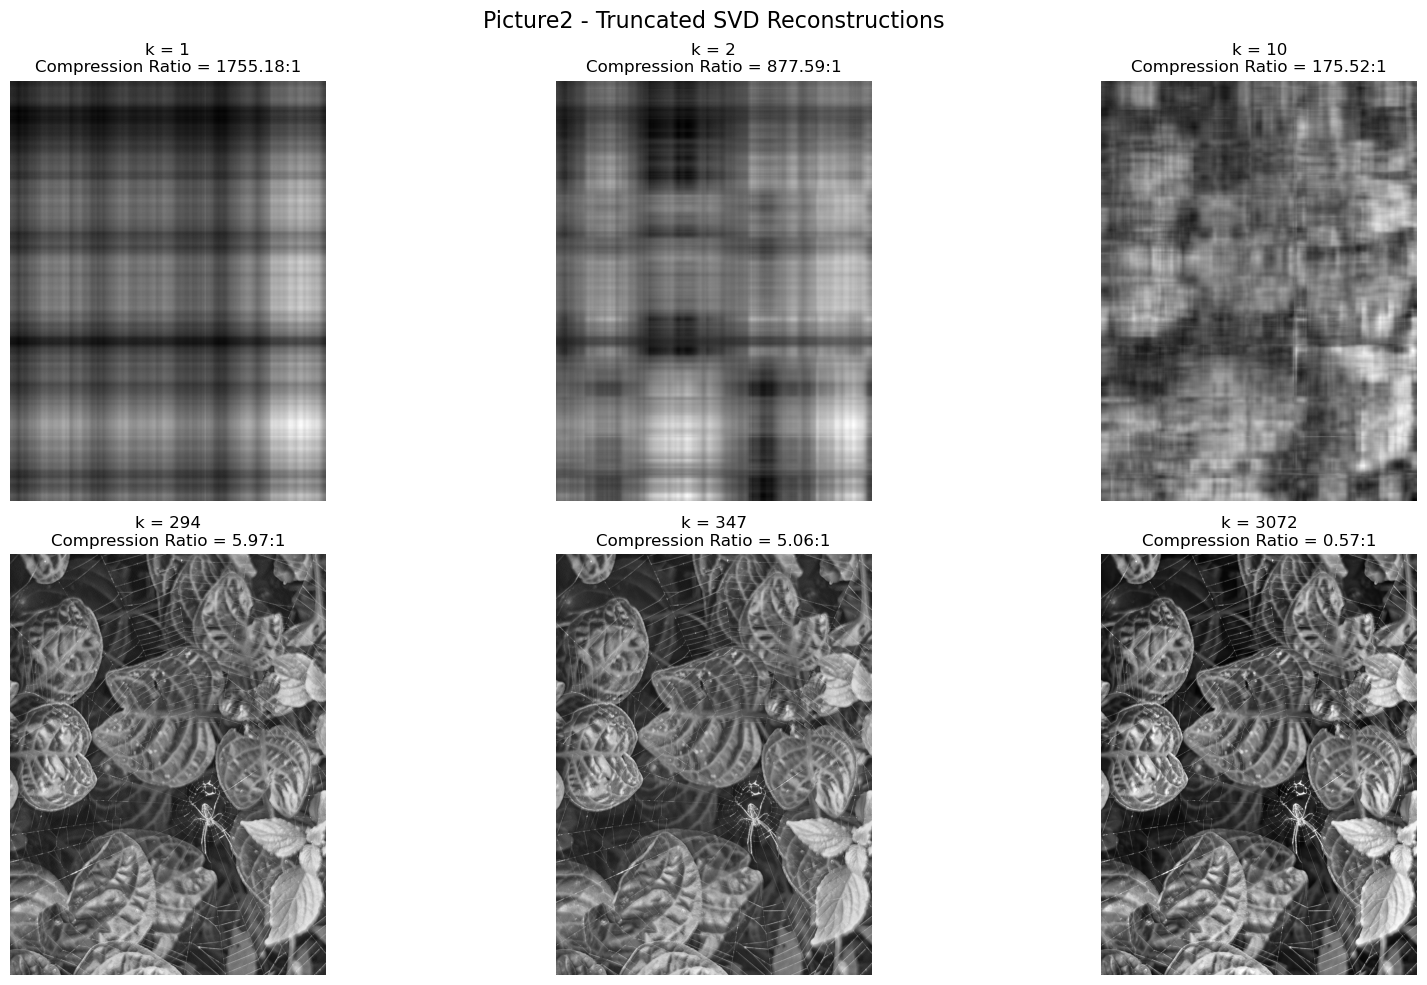

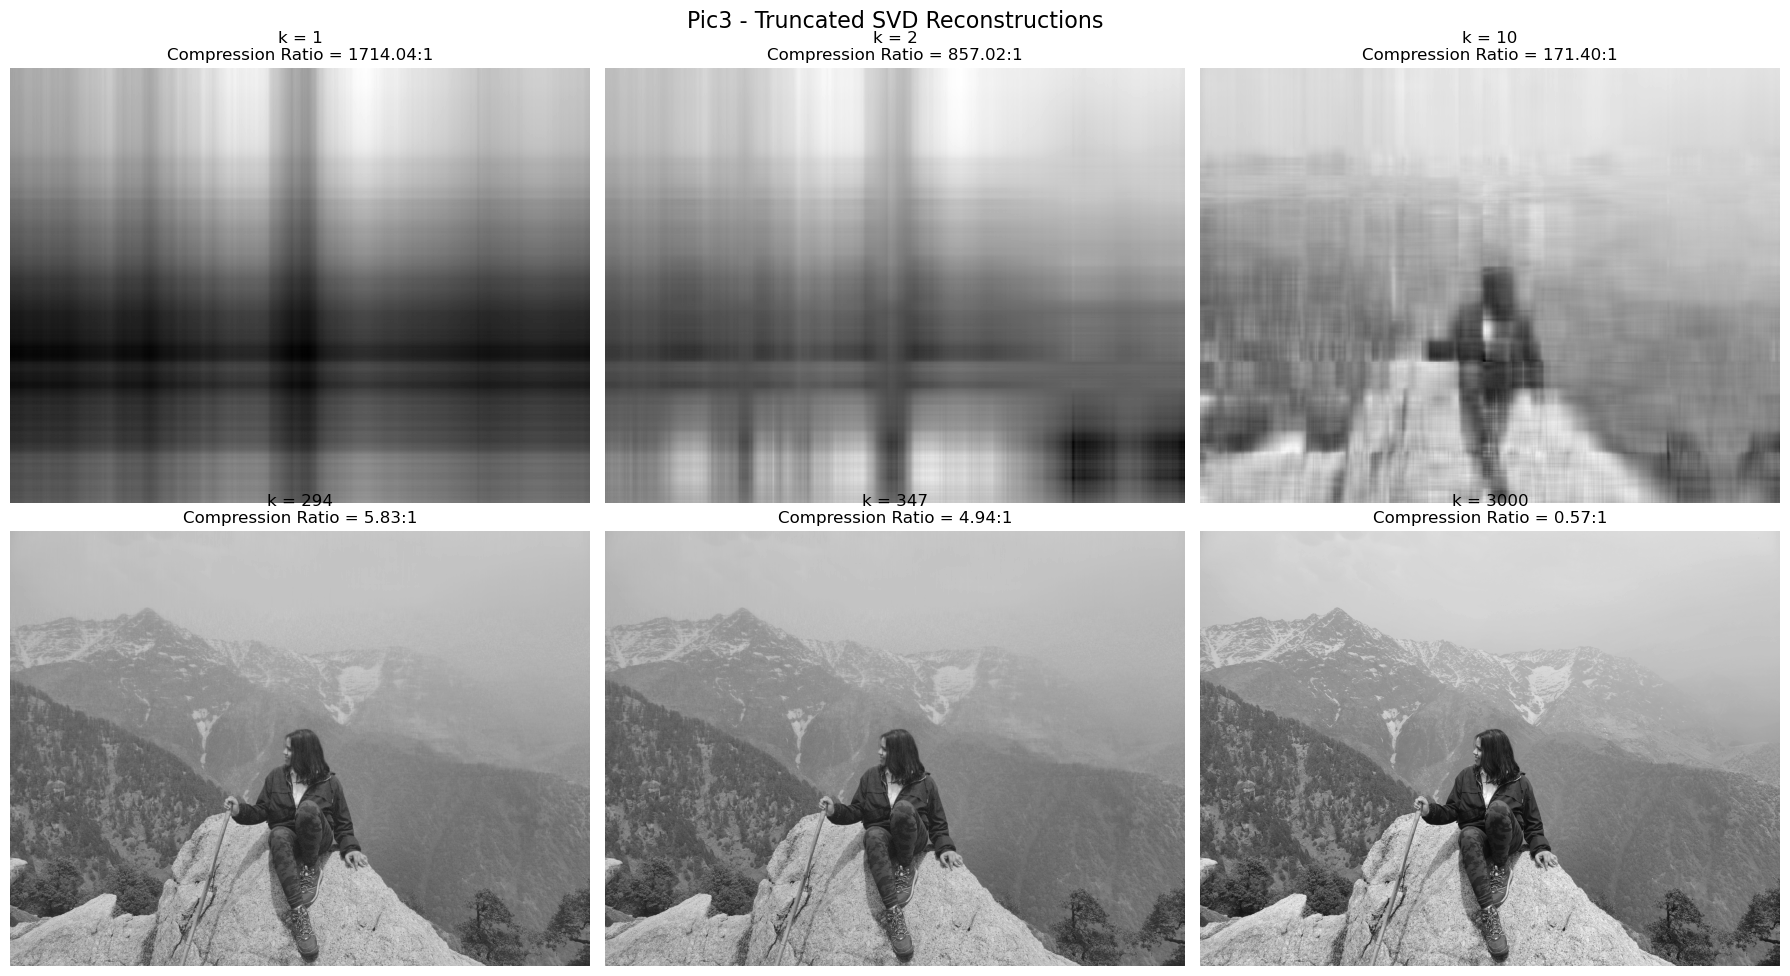

In [21]:
k_values_base = [1,2, 10, 294, 347]

for name, result in svd_results.items():

    U = result["U"]
    S = result["S"]
    Vt = result["Vt"]

    # Original image dimensions
    m, n = images[name].shape

    # Full rank
    full_rank = len(S)

    # Six k values
    k_values = k_values_base + [full_rank]

    plt.figure(figsize=(18, 10))

    for i, k in enumerate(k_values):

        # Reconstruct image
        reconstructed = reconstruct_image(
            U, S, Vt, k
        )

        # Calculate storage
        original_storage = m * n

        compressed_storage = (
            m * k + k + k * n
        )

        # Compression ratio
        compression_ratio = (
            original_storage / compressed_storage
        )

        # Plot
        plt.subplot(2, 3, i + 1)

        plt.imshow(
            reconstructed,
            cmap="gray"
        )

        plt.title(
            f"k = {k}\n"
            f"Compression Ratio = {compression_ratio:.2f}:1"
        )

        plt.axis("off")

    plt.suptitle(
        f"{name} - Truncated SVD Reconstructions",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

- Smaller k : More comression and lower quality
- larger k : less compression and better quality 

##### Which image compresses best, and why connect it to the structure in the picture, not just to the numbers.

Image structure is more strongly dominated by broad, smooth patterns. Smooth regions have high spatial redundancy, meaning neighboring pixels are similar.SVD can represent this kind of structure using only a few dominant components.
So Image 1 is the smoothest and compresses the best.

##### How does the singular value spectrum differ between the smooth image and the detailed one?

Smooth images tend to have rapidly decaying spectra and are more suitable for low-rank SVD compression, whereas detailed images have longer spectral tails and require larger values of k.

Picture1 compresses best because its structure is dominated by broad, relatively smooth patterns with high spatial redundancy. Its singular-value spectrum decreases very rapidly, indicating that most of its dominant structure can be represented using only a few components

### Add Gaussian noise to your smoothest image at two levels. What happens to the spectrum, and what does that imply about SVD as a denoising technique?

In [22]:
smoothest_name = "Picture1"

In [23]:
smooth_image = images[smoothest_name].copy()

print("shape:", smooth_image.shape)
print("min:", smooth_image.min())
print("max:", smooth_image.max())
print("mean:", smooth_image.mean())

shape: (3376, 6000)
min: 7.0
max: 246.0
mean: 216.75183624605054


In [24]:
smooth_image = images[smoothest_name].copy()

smooth_image = (
    smooth_image - smooth_image.min()
) / (
    smooth_image.max() - smooth_image.min()
)

print(smooth_image.min(), smooth_image.max())

0.0 1.0


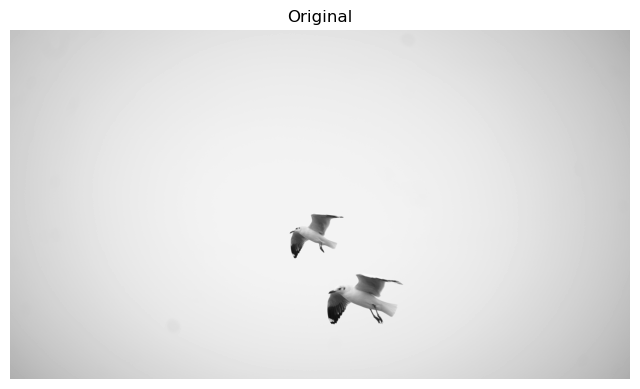

In [25]:
plt.figure(figsize=(8, 5))

plt.imshow(
    smooth_image,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.axis("off")
plt.title("Original")
plt.show()

In [29]:
#Adding the noise to the original image
noise_levels = [0.05, 0.20]
noisy_images = {}

for level in noise_levels:

    noise = np.random.normal(
        0,
        level,
        smooth_image.shape
    )

    noisy_images[level] = np.clip(
        smooth_image + noise,
        0,
        1
    )

In [30]:
for level, noisy in noisy_images.items():
    print(
        level,
        noisy.min(),
        noisy.max(),
        noisy.mean()
    )

0.05 0.0 1.0 0.876540330952991
0.2 0.0 1.0 0.8410925368372691


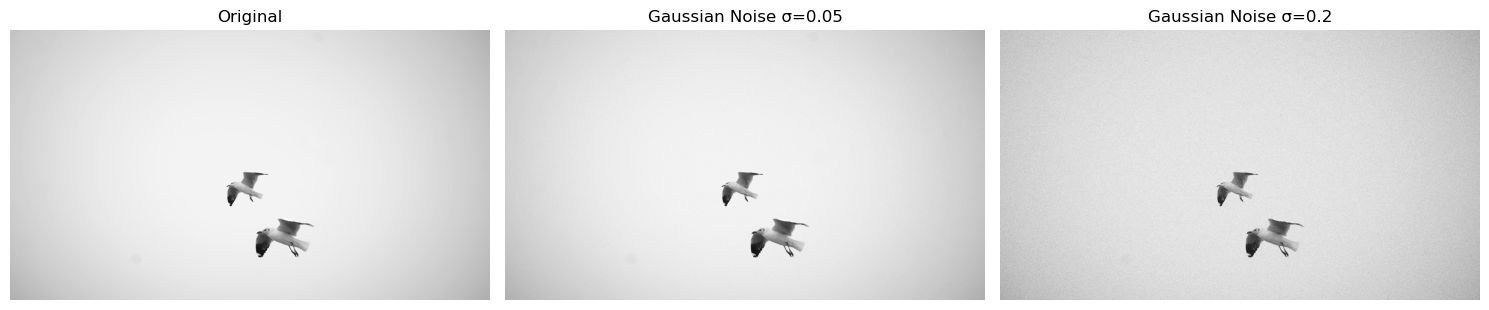

In [31]:
#Dsiplaying
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(
    smooth_image,
    cmap="gray",
    vmin=0,
    vmax=1
)
axes[0].set_title("Original")

for ax, (level, noisy) in zip(axes[1:], noisy_images.items()):

    ax.imshow(
        noisy,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax.set_title(f"Gaussian Noise σ={level}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Adding Gaussian noise progressively degrades the smooth image. At σ = 0.05, the noise is relatively subtle from the main image. At σ = 0.20, the background becomes noticeably grainier, although the main objects remain identifiable.
We can see how increasing noise introduces additional high-frequency variations into the image.